In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('medical_insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info

<bound method DataFrame.info of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
2767   47  female  45.320         1     no  southeast   8569.86180
2768   21  female  34.600         0     no  southwest   2020.17700
2769   19    male  26.030         1    yes  northwest  16450.89470
2770   23    male  18.715         0     no  northwest  21595.38229
2771   54    male  31.600         0     no  southwest   9850.43200

[2772 rows x 7 columns]>

### EDA

In [6]:
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### Numerical:
age
bmi
children
charges (target)
### Categorical:
sex
smoker
region


### For Numerical Variable

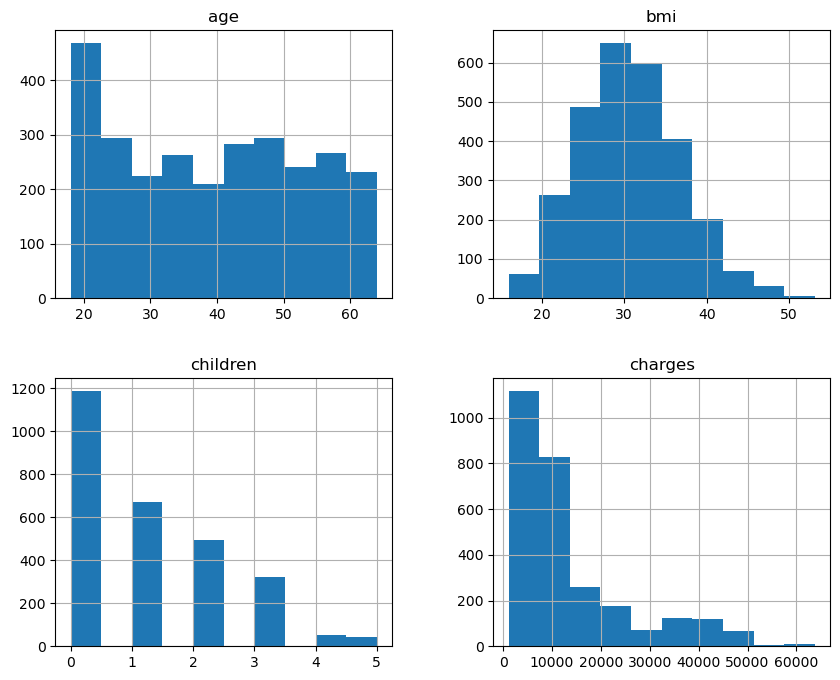

In [7]:
import matplotlib.pyplot as plt
df.hist(figsize=(10,8))
plt.show()

.The distribution of age is remarkably uniform across most of the range (20 to 60 years), indicating a balanced demographic sample. However, there is a distinct spike in the 18–22 age group,
.The Body Mass Index (BMI) follows a Normal (Gaussian) distribution, centered at approximately 30.
.The "children" graph is right-skewed, with the vast majority of policyholders having zero children.
.Medical charges are heavily right-skewed, showing that most people incur relatively low costs (under $15,000).

### For Categorical Variable

<Axes: xlabel='sex', ylabel='count'>

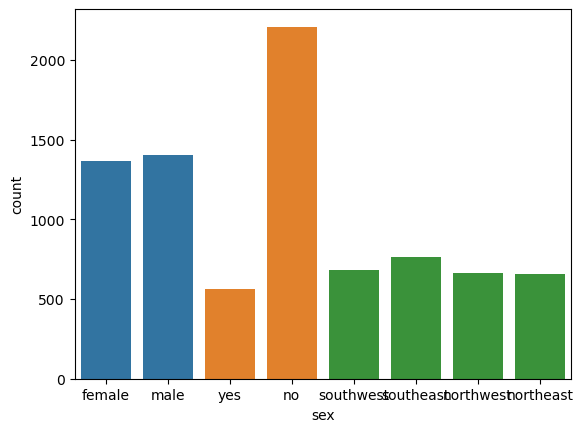

In [8]:
import seaborn as sns

sns.countplot(x='sex', data=df)
sns.countplot(x='smoker', data=df)
sns.countplot(x='region', data=df)

.The dataset shows a balanced gender distribution
.There is a massive disparity in smoking status. The number of non-smokers (over 2,200) far outweighs the number of smokers (roughly 550).
.The policyholders are distributed uniformly across the four regions (Southwest, Southeast, Northwest, and Northeast).

##### Bivariate Analysis
Numerical vs Target

<Axes: xlabel='age', ylabel='charges'>

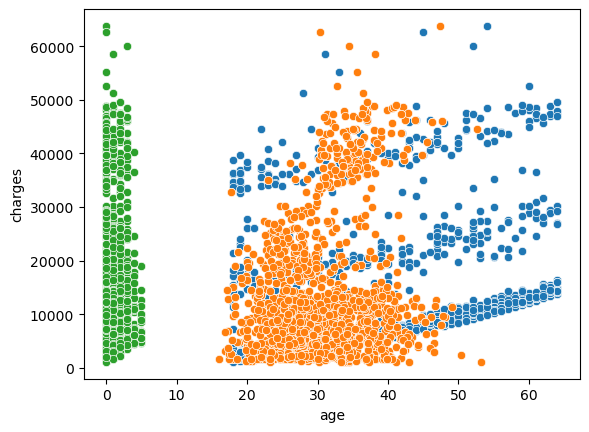

In [9]:
sns.scatterplot(x='age', y='charges', data=df)
sns.scatterplot(x='bmi', y='charges', data=df)
sns.scatterplot(x='children', y='charges', data=df)

.There is a clear positive correlation between age and medical charges
.The scatterplot for BMI (orange dots) shows a significant "explosion" in charges once BMI exceeds 30. Below 30, charges remain relatively low and stable. Above 30, we see a massive vertical spread reaching up to $60,000.
.The green dots represent the number of children (0 to 5). Because this is a discrete variable, the data forms vertical pillars. The insight here is that while individuals with 0–3 children show a full range of charges (including the highest outliers), those with 4 or 5 children generally show lower maximum charges.



Categorical vs Target

<Axes: xlabel='smoker', ylabel='charges'>

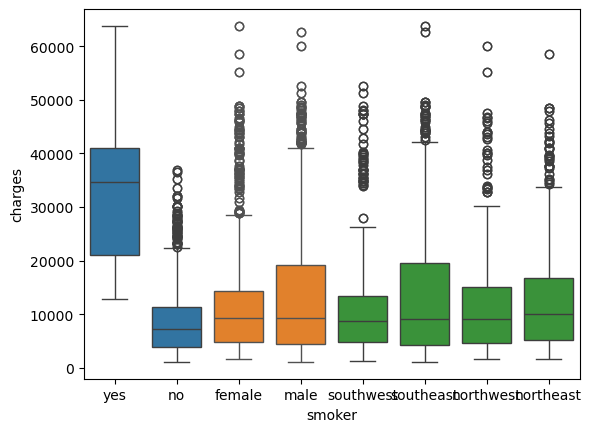

In [10]:
sns.boxplot(x='smoker', y='charges', data=df)
sns.boxplot(x='sex', y='charges', data=df)
sns.boxplot(x='region', y='charges', data=df)

Smoking is the primary driver of high medical charges, while gender and region show relatively uniform distributions with numerous high-cost outliers.

Correlation Analysis

<Axes: >

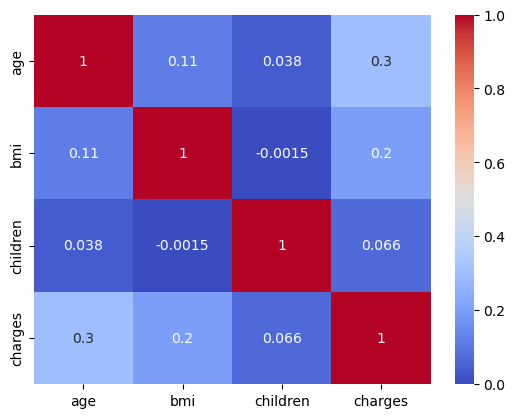

In [11]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

Age and BMI show moderate positive correlations with charges, while the number of children has a negligible impact on overall medical costs.

<Axes: xlabel='bmi'>

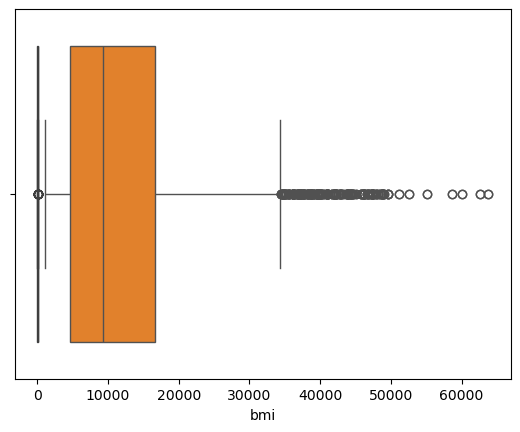

In [12]:
sns.boxplot(x=df['bmi'])
sns.boxplot(x=df['charges'])

While the BMI distribution is relatively compact with few outliers, the charges distribution is highly skewed with a massive concentration of high-value outliers beyond the upper whisker.

Distribution of Target

<Axes: xlabel='charges', ylabel='Count'>

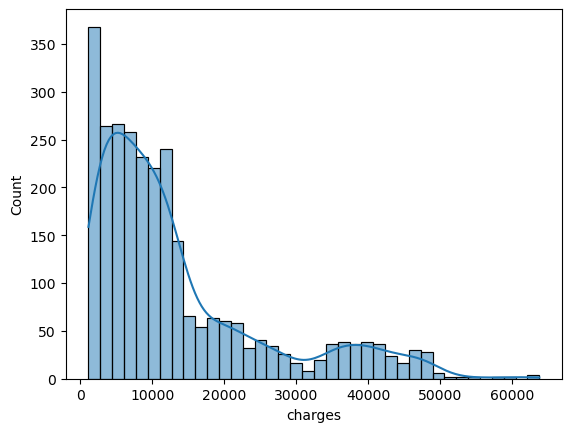

In [13]:
sns.histplot(df['charges'], kde=True)

The insurance charges exhibit a multi-modal, right-skewed distribution, with a primary peak at low costs and secondary clusters around $40,000 representing high-risk subgroups.

#### Key Insights

Smoking is the strongest factor affecting charges
Age and BMI have positive correlation
Charges are right-skewed
Region and sex have less impact
Dataset has no missing values

#### Data Preprocessing using Column Transformer

In [22]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Load data
df = pd.read_csv('medical_insurance.csv')

# Clean column names (good practice)
df.columns = df.columns.str.strip().str.lower()

# Define X and y
y = df['charges']
X = df.drop('charges', axis=1)

# Feature types
numeric_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker' , 'region']  

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ],
    remainder='passthrough'
)

# Apply transformation
X_processed = preprocessor.fit_transform(X)

## Pipline for Regression

In [25]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [28]:
# Train model
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', LinearRegression())])

In [30]:
y_pred = pipeline.predict(X_test)

#### Model Evaluation

In [34]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.9504910496106208
RMSE: 2756.5705313930725
MAE: 1283.2537698640726


## Random Forest Regression Pipeline

In [36]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y, test_size=0.2, random_state=50
)


In [41]:
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=50))
])

pipeline.fit(X_train1, y_train1)
y_pred1 = pipeline.predict(X_test1)

In [65]:
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', RandomForestRegressor(random_state=42))])

#### Model Evaluation

In [43]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

print("R2 Score:", r2_score(y_test1, y_pred1))
print("RMSE:", np.sqrt(mean_squared_error(y_test1, y_pred1)))
print("MAE:", mean_absolute_error(y_test1, y_pred1))

R2 Score: 0.9544516717588434
RMSE: 2787.2048233045193
MAE: 1341.657136323958


## Ridge Regression Pilpline

In [45]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.2, random_state=88
)


In [67]:
from sklearn.linear_model import Ridge

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])
pipeline.fit(X_train2, y_train2)
y_pred2 = pipeline.predict(X_test2)

In [68]:
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', Ridge())])

#### Model Evaluation

In [49]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

print("R2 Score:", r2_score(y_test2, y_pred2))
print("RMSE:", np.sqrt(mean_squared_error(y_test2, y_pred2)))
print("MAE:", mean_absolute_error(y_test2, y_pred2))

R2 Score: 0.740871045020028
RMSE: 5965.490296386857
MAE: 4145.316628354053


## GridSearch with Pipeline

In [69]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X, y, test_size=0.2, random_state=88
)

In [70]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

In [71]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [None, 5, 10]
}
grid = GridSearchCV(pipeline, param_grid, cv=5)
grid.fit(X_train3, y_train3)
y_pred3 = grid.predict(X_test3)

In [73]:
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', RandomForestRegressor(random_state=42))])

#### Model Evaluation

In [64]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

print("R2 Score:", r2_score(y_test3, y_pred3))
print("RMSE:", np.sqrt(mean_squared_error(y_test3, y_pred3)))
print("MAE:", mean_absolute_error(y_test3, y_pred3))

R2 Score: 0.9178084170500315
RMSE: 3359.7104033647097
MAE: 1480.3133708407977


## Lasso Regression with Pipeline

In [74]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train4, X_test4, y_train4, y_test4 = train_test_split(
    X, y, test_size=0.2, random_state=88
)

In [82]:
from sklearn.linear_model import Lasso

lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso())
])
lasso_pipeline.fit(X_train4, y_train4)
y_pred4 = lasso_pipeline.predict(X_test4)

In [81]:
lasso_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', Lasso())])

### Model Evaluation

In [55]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

print("R2 Score:", r2_score(y_test4, y_pred4))
print("RMSE:", np.sqrt(mean_squared_error(y_test4, y_pred4)))
print("MAE:", mean_absolute_error(y_test4, y_pred4))

R2 Score: 0.740871045020028
RMSE: 5965.490296386857
MAE: 4145.316628354053


## Pipeline for Polynomial Regression

In [56]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train5, X_test5, y_train5, y_test5 = train_test_split(
    X, y, test_size=0.2, random_state=88
)

In [57]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # your existing preprocessing
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])

In [59]:
poly_pipeline.fit(X_train5, y_train5)
y_pred5 = poly_pipeline.predict(X_test5)

In [ ]:
poly_pipeline

### Model Evaluation

In [60]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

print("R2 Score:", r2_score(y_test5, y_pred5))
print("RMSE:", np.sqrt(mean_squared_error(y_test5, y_pred5)))
print("MAE:", mean_absolute_error(y_test5, y_pred5))

R2 Score: 0.8330435642223585
RMSE: 4788.392635311373
MAE: 2901.2625611429085
